
# <span style="color:rgb(213,80,0)">1D Compositional Simulation with Bio\-Clogging (MRST\-style, release\-ready)</span>

This MRST example demonstrates a 1D two\-phase compositional simulation with and without bio\-clogging effects in a porous medium. The simulation includes: \- Initial fluid mixture with configurable H2 content (high or low) \- Bio\-clogging effects: porosity and permeability reduction due to bacterial growth \- Soreide\-Whitson equation of state (EOS) for compositional fluids \- LBC viscosity correlation for multi\-phase flow \- Relative permeability functions accounting for residual saturations \- Comparison of three scenarios: 1) With bacterial effects and bio\-clogging 2) With bacterial effects but no clogging 3) Without bacterial effects (abiotic)


This example is suitable for testing MRST compositional solvers, bio\-chemical extensions, and the impact of microbial activity on flow.


Reference: [https://www.sciencedirect.com/science/article/pii/S0360319925039473](https://www.sciencedirect.com/science/article/pii/S0360319925039473)


In [1]:
mrstModule add ad-core ad-props deckformat mrst-gui
mrstModule add compositional
mrstVerbose off;

## Setup base compositional model

In [2]:
[~, model, schedule, ~] = setupSimpleCompositionalExample(false);

## Mimic simple well effects by altering boundary cells

Increase porosity in boundary cells.


In [3]:
model.rock.poro([1, end]) = 0.90;   % First and last cell porosity

% Define reference densities for phases at standard conditions.
model.fluid.rhoGS = 0.08988;   % Hydrogen-like gas density at STP [kg/m^3]
model.fluid.rhoOS = 999.0140;    % Water-like liquid density at STP [kg/m^3]
% Shorten schedule for faster simulation
schedule.step.val     = schedule.step.val/3;
schedule.step.val     = schedule.step.val(1:50);
schedule.step.control = schedule.step.control(1:50);

## EOS setup: Soreide\-Whitson

In [4]:
model.EOSModel = SoreideWhitsonEos( ...
    model.G, model.EOSModel.CompositionalMixture, 'msalt', 5);

## Residual saturations and relperm adjustments

Define residual saturations for water, gas, and oil.


In [5]:
swc   = 0.20;   % Connate water saturation
sor   = 0.20;   % Residual oil saturation
sgr   = 0.10;   % Residual gas saturation
swmax = 0.90;   % Maximum water saturation (oil/gas nearly absent)
sgmax = 0.80;   % Maximum gas saturation (oil/water nearly absent)

% Update relative permeability functions to include residual saturations
model.fluid = modifyRelPermForResidualSaturations( ...
    model.fluid, swc, swmax, sgr, sor, sgmax);

## Initial conditions

In [6]:
%--------------------------------------------------------------------------
% Default initial overall composition [H2O, H2, C1, CO2, CH3COOH]
initComp  = [0.90, 0.045, 0.005, 0.05, 0.0];

% Alternative: test with higher hydrogen content
% initComp = [0.40, 0.445, 0.055, 0.10];

% Thermodynamic conditions
initTemp  = 273.15 + 40;   % Absolute temperature [K]
initPress = 82*barsa;      % Pressure [Pa]

% Metabolic reaction
 %biochemFluid = TableBioChemMixture({'MethanogenicArchae'},{'nbactM'});
 biochemFluid = TableBioChemMixture({'MethanogenicArchae','AcetogenicBacteria'},{'nbactM','nbactA'});

## Bio\-clogging model

In [7]:
nbioreact=biochemFluid.nbioreact;
initBact = ones(1, nbioreact) * 9;              % Normalized bacteria concentration
nc = ones(1, nbioreact) * 180;                 % critical bacteria concentration
cp = zeros(1, nbioreact);                      % scaling coefficient

% Use appropriate setup function based on number of reactors
if nbioreact == 1
    [model, poro0, perm0] = setupBioCloggingModel(model, initBact(1), nc(1), cp(1));
else
    [model, poro0, perm0] = setupBioCloggingModel2bacts(model, initBact, nc, cp);
end

## Biochemistry model wrapper

In [8]:
compFluid = TableCompositionalMixture( ...
    {'Water','Hydrogen','Methane','CarbonDioxide','AceticAcid'}, ...
    {'H2O','H2','C1','CO2','CH3COOH'});

backend = DiagonalAutoDiffBackend('modifyOperators', true);
model   = BiochemistryModel(model.G, model.rock, model.fluid, compFluid,...
    biochemFluid, true, backend, 'water', false, 'oil', true, 'gas', true, ...
    'bacteriamodel', true,'moleculardiffusion', true, 'liquidPhase','O','vaporPhase','G');

## Shut Wells

In [9]:
schedule.control.W(1).components = [0.001, 0.958, 0.001, 0.05,0.0];
schedule.control.W(2).components = [0.001, 0.998, 0.001, 0.05,0.0];
schedule.control.W(1).type = 'rate'; schedule.control.W(1).val = 0;
schedule.control.W(2).type = 'rate'; schedule.control.W(2).val = 0;

## Initialize state

In [10]:
state0 = initCompositionalStateBacteria(model, initPress, initTemp, [0,1], ...
    initComp, initBact, model.EOSModel);

## Scenario 1: with bacterial clogging

In [11]:
prob1 = packSimulationProblem(state0, model, schedule, 'bio_cloggingMA');
prob1.SimulatorSetup.model.OutputStateFunctions{end} = 'ComponentPhaseMass';
simulatePackedProblem(prob1);

**********************************************
* Case "bio_cloggingMA" (BiochemistryModel)  *
* Description: "BiochemistryModel"           *
**********************************************
-> Complete output found, nothing to do here.

In [12]:
[ws1, st1] = getPackedSimulatorOutput(prob1);

Found complete data for bio_cloggingMA (BiochemistryModel): 50 steps present

## Scenario 2: bacteria but no clogging

In [13]:
model2 = model;
model2.rock.perm = perm0;
model2.rock.poro = poro0;
% Create pvMultR function that accepts any number of bacterial arguments
model2.fluid.pvMultR = @(p, varargin) ones(size(p));

%model2.fluid.pvMultR = @(p,nb) 1;
prob2 = packSimulationProblem(state0, model2, schedule, 'bio_no_clogMA');
prob2.SimulatorSetup.model.OutputStateFunctions{end} = 'ComponentPhaseMass';
simulatePackedProblem(prob2);

*********************************************
* Case "bio_no_clogMA" (BiochemistryModel)  *
* Description: "BiochemistryModel"          *
*********************************************
-> Complete output found, nothing to do here.

In [14]:
[ws2, st2] = getPackedSimulatorOutput(prob2);

Found complete data for bio_no_clogMA (BiochemistryModel): 50 steps present

## Scenario 3: abiotic (no bacteria)

In [15]:
model3 = model2; model3.bacteriamodel = false;
state3 = state0; % same state without bacteria effects
prob3 = packSimulationProblem(state3, model3, schedule, 'no_bacteriaMA');
prob3.SimulatorSetup.model.OutputStateFunctions{end} = 'ComponentPhaseMass';
simulatePackedProblem(prob3);

*********************************************
* Case "no_bacteriaMA" (BiochemistryModel)  *
* Description: "BiochemistryModel"          *
*********************************************
-> Complete output found, nothing to do here.

In [16]:
[ws3, st3] = getPackedSimulatorOutput(prob3);

Found complete data for no_bacteriaMA (BiochemistryModel): 50 steps present

## Compare scenarios

In [17]:
compNames = model.EOSModel.getComponentNames();
idxH2  = find(strcmp(compNames,'H2'));
idxCO2 = find(strcmp(compNames,'CO2'));
idxCH4 = find(strcmp(compNames,'C1'));

timeDays = cumsum(schedule.step.val)/day;
timeYrs  = timeDays/365;

scenarios = {
    struct('name','Bio-Clog','model', model,'states',{st1},'color',[0 0.5 0],'line','-'), ...
    struct('name','Bio-NoClog','model', model2, 'states',{st2},'color',[0 0.7 0.7],'line','--'), ...
    struct('name','Abiotic','model', model3,'states',{st3},'color',[0.7 0 0],'line',':')};

## Plot results


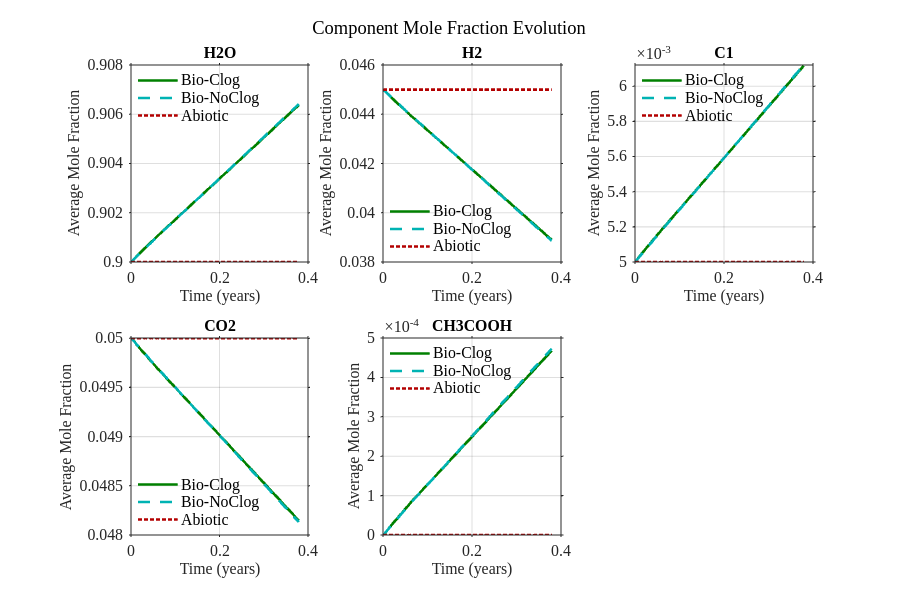

In [18]:
plotComponentProfiles(scenarios, compNames, timeYrs);


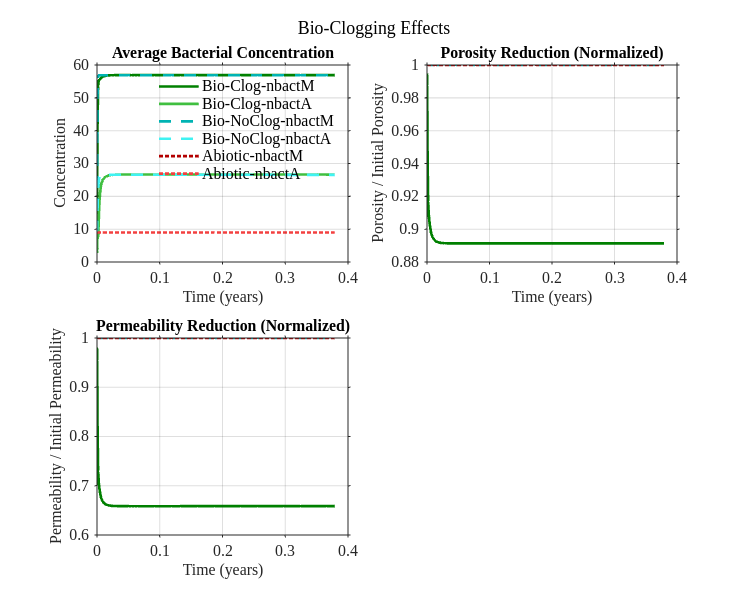

In [19]:
plotBacterialEffects(scenarios, timeYrs, poro0, perm0);


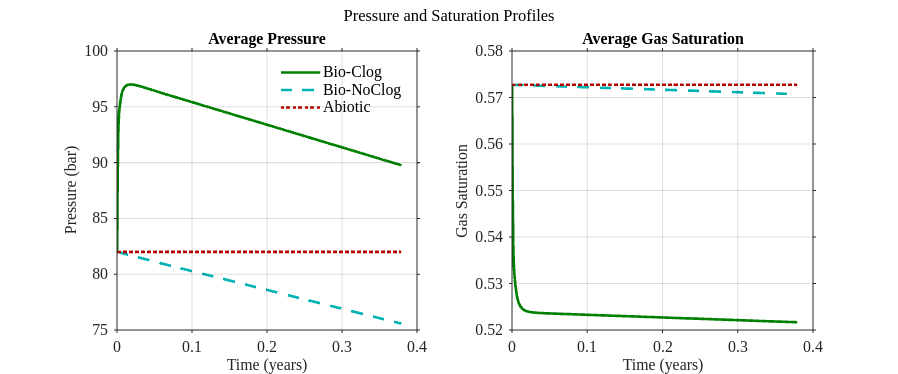

In [20]:
plotPressureAndSaturation(scenarios, timeYrs);


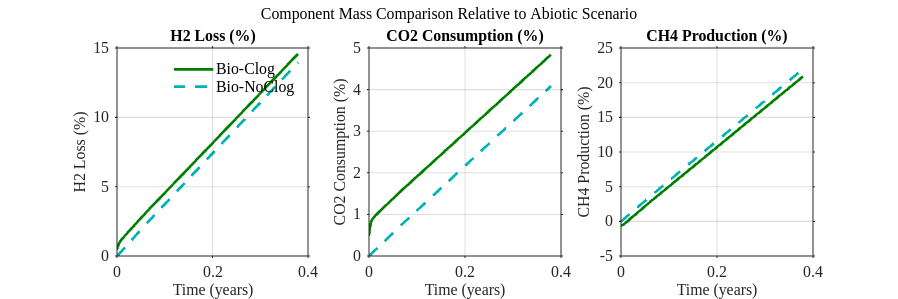

In [21]:
plotComponentComparison(scenarios, timeYrs, idxH2, idxCO2, idxCH4);

In [22]:

%plotToolbar(model.G, st1, 'plot1d', true, 'field','pressure');
% title('Bio-Clogging Scenario - Pressure');

## Copyright notice

In [23]:
% <html>
% <p><font size="-1">
% Copyright 2009-2026 SINTEF Digital, Mathematics & Cybernetics.
% </font></p>

% <p><font size="-1">
% This file is part of The MATLAB Reservoir Simulation Toolbox (MRST).
% </font></p>

% <p><font size="-1">
% MRST is free software: you can redistribute it and/or modify
% it under the terms of the GNU General Public License as published by
% the Free Software Foundation, either version 3 of the License, or
% (at your option) any later version.
% </font></p>

% <p><font size="-1">
% MRST is distributed in the hope that it will be useful,
% but WITHOUT ANY WARRANTY; without even the implied warranty of
% MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
% GNU General Public License for more details.
% </font></p>

% <p><font size="-1">
% You should have received a copy of the GNU General Public License
% along with MRST.  If not, see
% <a href="http://www.gnu.org/licenses/">http://www.gnu.org/licenses</a>.
% </font></p>

% </html>